**Image Classification Using CNN**

CIFAR-10 Image Classification
This project develops a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify images from the CIFAR-10 dataset into 10 different categories.

In [ ]:
#Importing Necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

In [ ]:
#Loading CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1677s 10us/step


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    # Third convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Convert feature maps to vector
    layers.Flatten(),
    # Fully connected layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    # Output layer for 10 CIFAR-10 classes
    layers.Dense(10, activation='softmax')
])

In [ ]:
# Compile the CNN model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Checking the current Labels
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 y_train labels:")
print(y_train[:5])

y_train shape: (50000, 1)
y_test shape: (10000, 1)

First 5 y_train labels:
[[6]
 [9]
 [9]
 [4]
 [1]]


In [ ]:
#Convert to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

#Checking the Converted labels
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

print("\nFirst 5 y_train_cat labels:")
print(y_train_cat[:5])


y_train_cat shape: (50000, 10)
y_test_cat shape: (10000, 10)

First 5 y_train_cat labels:
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3260 - loss: 1.7980 - val_accuracy: 0.4696 - val_loss: 1.4673
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4634 - loss: 1.4896 - val_accuracy: 0.5294 - val_loss: 1.3289
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5095 - loss: 1.3698 - val_accuracy: 0.5508 - val_loss: 1.2567
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5371 - loss: 1.2974 - val_accuracy: 0.5799 - val_loss: 1.1778
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5627 - loss: 1.2366 - val_accuracy: 0.6138 - val_loss: 1.0918
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5773 - loss: 1.2019 - val_accuracy: 0.6277 - val_loss: 1.0556
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5957 - loss: 1.1485 - val_accuracy: 0.6487 - val_loss: 1.0165
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6059 - loss: 1.1195 - val_accuracy: 0

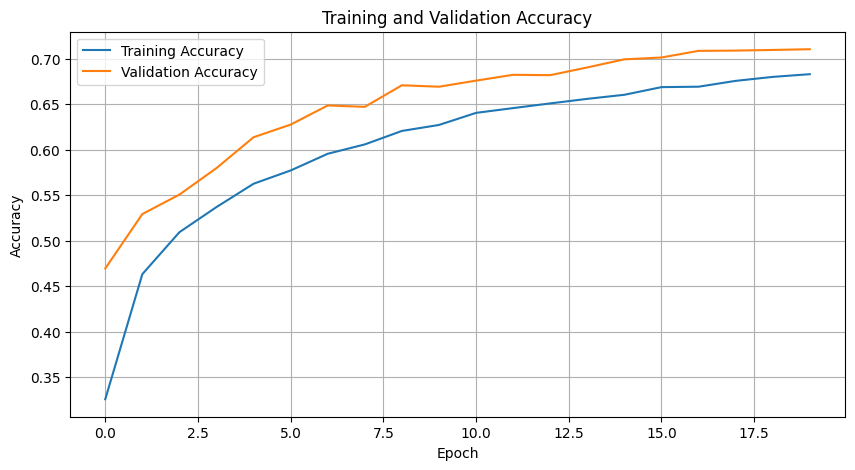

In [ ]:
#Ploting Training and Validation Accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

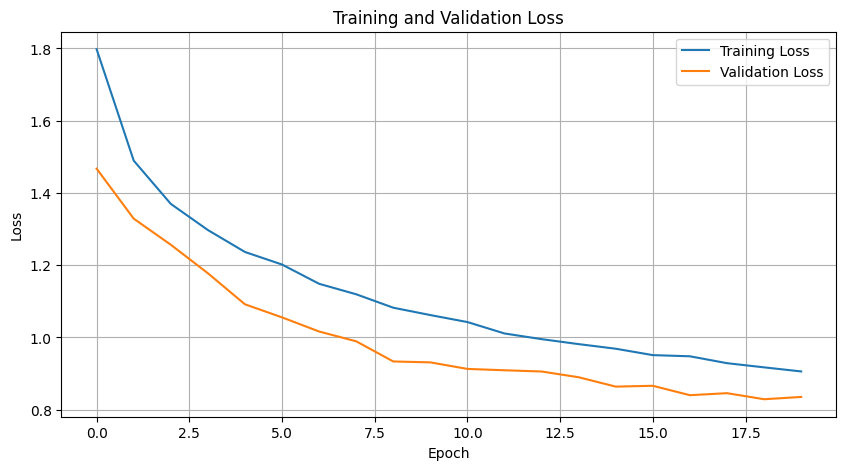

In [ ]:
#Ploting Training and Validation Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Evaluate the CNN model on the test dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=1
)

print("\n==============================")
print("MODEL EVALUATION RESULTS")
print("==============================")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7011 - loss: 0.8563

MODEL EVALUATION RESULTS
Test Loss: 0.8563
Test Accuracy: 0.7011
Test Accuracy: 70.11%


In [ ]:
# Predict classes for all test images

y_pred_probability = model.predict(x_test)

# Convert prediction probabilities into class numbers

y_pred = np.argmax(y_pred_probability, axis=1)

# Convert actual labels into a 1D array

y_true = y_test.flatten()

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_true[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predictions generated successfully!

First 10 predictions:
[3 8 8 0 6 6 1 6 3 1]

First 10 actual labels:
[3 8 8 0 6 6 1 6 3 1]


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


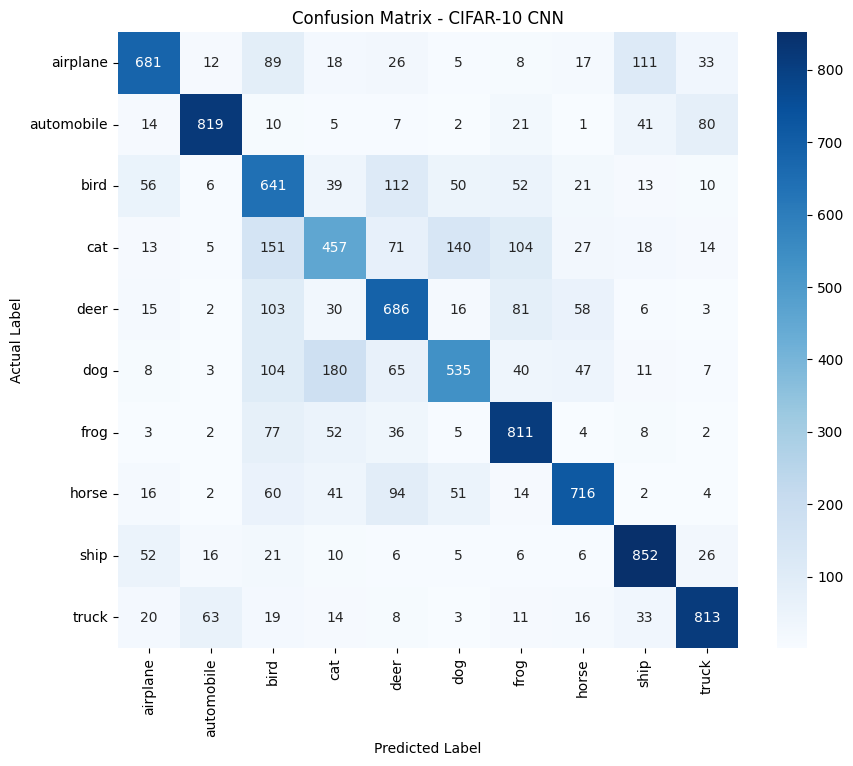

In [ ]:
# Plot the confusion matrix for better visualization
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - CIFAR-10 CNN")

plt.show()

In [ ]:
#Getting Classification reort
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.78      0.68      0.73      1000
  automobile       0.88      0.82      0.85      1000
        bird       0.50      0.64      0.56      1000
         cat       0.54      0.46      0.50      1000
        deer       0.62      0.69      0.65      1000
         dog       0.66      0.54      0.59      1000
        frog       0.71      0.81      0.76      1000
       horse       0.78      0.72      0.75      1000
        ship       0.78      0.85      0.81      1000
       truck       0.82      0.81      0.82      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



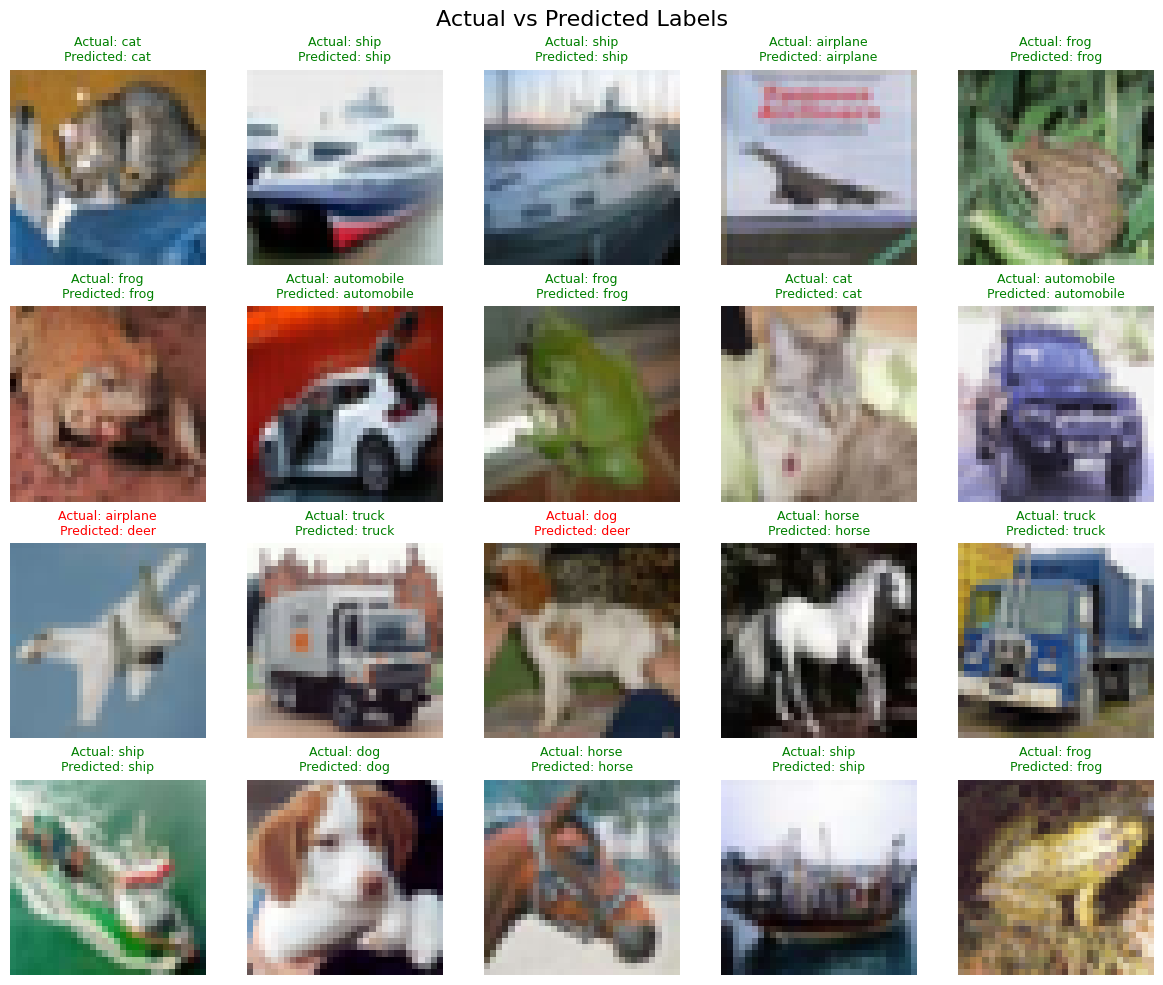

In [ ]:
# DIsplaying Actual vs Predicted Images
plt.figure(figsize=(12, 10))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    # Display image
    plt.imshow(x_test[i])

    # Get actual and predicted labels
    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    # Color title based on correct/incorrect prediction
    if actual == predicted:
        title_color = 'green'
    else:
        title_color = 'red'

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=9,
        color=title_color
    )

    plt.axis('off')

plt.suptitle(
    "Actual vs Predicted Labels",
    fontsize=16
)

plt.tight_layout()
plt.show()

Data augmentation generator created successfully!


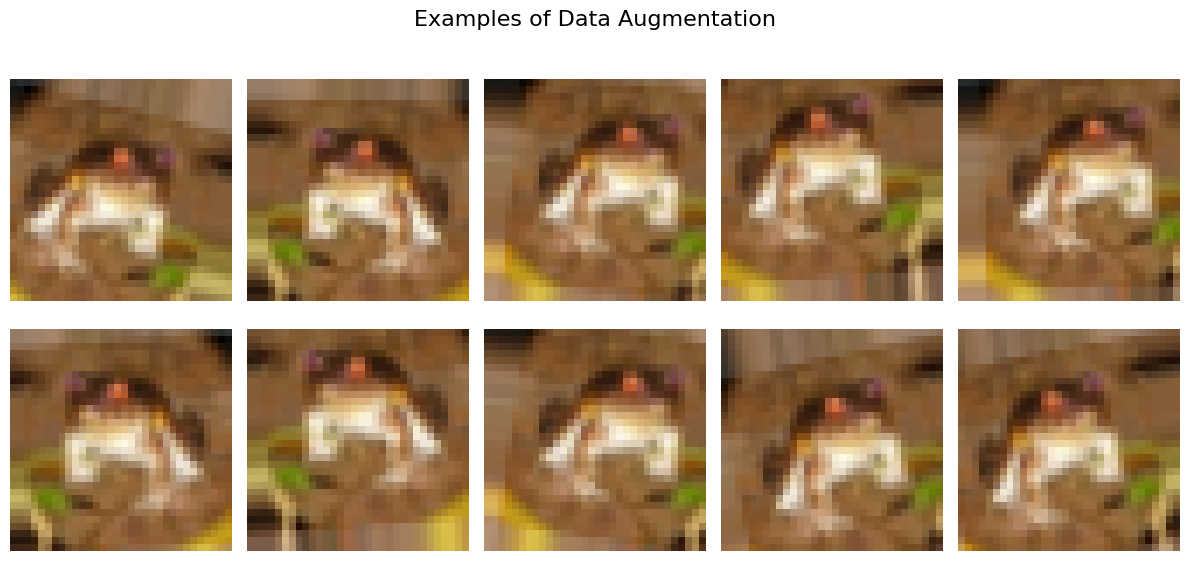

In [ ]:
#Importing ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Create the Data Augmentation Generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
print("Data augmentation generator created successfully!")

#Visualizing Augmented Images
# Select one training image
sample_image = x_train[0].reshape((1, 32, 32, 3))

# Generate augmented images
augmented_images = datagen.flow(
    sample_image,
    batch_size=1
)

plt.figure(figsize=(12, 6))

for i in range(10):

    augmented_image = next(augmented_images)[0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_image)
    plt.axis('off')

plt.suptitle("Examples of Data Augmentation", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
#Creating the Augmented CNN Model
model_aug = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    # Output layer: 10 CIFAR-10 classes
    layers.Dense(10, activation='softmax')
])

model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the Augmented Model
model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Augmented model compiled successfully!")

Augmented model compiled successfully!


In [ ]:
from sklearn.model_selection import train_test_split

x_train_aug, x_val, y_train_aug, y_val = train_test_split(
    x_train,
    y_train_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
history_aug = model_aug.fit(
    datagen.flow(
        x_train_aug,
        y_train_aug,
        batch_size=64
    ),
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.2897 - loss: 1.9013 - val_accuracy: 0.4652 - val_loss: 1.5096
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.4109 - loss: 1.6064 - val_accuracy: 0.5117 - val_loss: 1.3789
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.4574 - loss: 1.4985 - val_accuracy: 0.5399 - val_loss: 1.2744
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.4825 - loss: 1.4488 - val_accuracy: 0.5736 - val_loss: 1.1990
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5018 - loss: 1.3952 - val_accuracy: 0.5528 - val_loss: 1.2138
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.5155 - loss: 1.3625 - val_accuracy: 0.6048 - val_loss: 1.1199
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5307 - loss: 1.3271 - val_accuracy: 0.5944 - val_loss: 1.1410
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.5407 - loss: 1.2975 - 

In [ ]:
# Evaluate the augmented CNN model on the unseen test dataset

aug_test_loss, aug_test_accuracy = model_aug.evaluate(
    x_test,
    y_test_cat,
    verbose=1
)

print("\n==============================")
print("AUGMENTED CNN EVALUATION")
print("==============================")

print(f"Test Loss: {aug_test_loss:.4f}")
print(f"Test Accuracy: {aug_test_accuracy:.4f}")
print(f"Test Accuracy: {aug_test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6771 - loss: 0.9231

AUGMENTED CNN EVALUATION
Test Loss: 0.9231
Test Accuracy: 0.6771
Test Accuracy: 67.71%


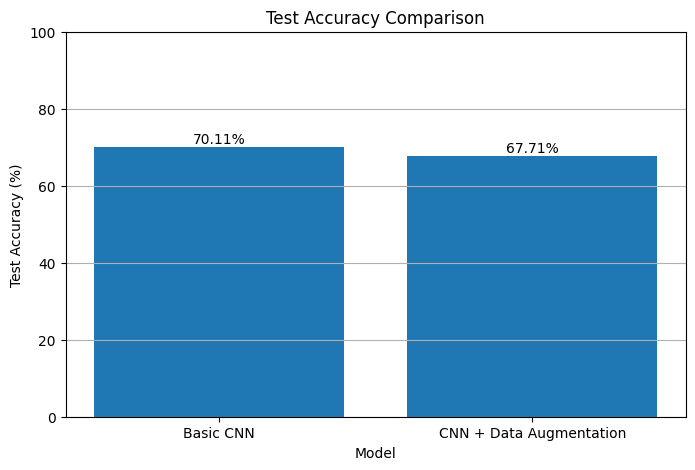

In [ ]:
# Compare Basic CNN and Augmented CNN

model_names = [
    'Basic CNN',
    'CNN + Data Augmentation'
]

test_accuracies = [
    test_accuracy * 100,
    aug_test_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(model_names, test_accuracies)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

plt.ylim(0, 100)

for i, accuracy in enumerate(test_accuracies):
    plt.text(
        i,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha='center'
    )

plt.grid(axis='y')
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Basic CNN',
        'CNN + Data Augmentation'
    ],
    'Test Accuracy (%)': [
        test_accuracy * 100,
        aug_test_accuracy * 100
    ],
    'Test Loss': [
        test_loss,
        aug_test_loss
    ]
})

comparison

,Model,Test Accuracy (%),Test Loss
0,Basic CNN,70.109999,0.856324
1,CNN + Data Augmentation,67.710000,0.923054
